# Trajectory buffers

GPU-resident sampling trajectory for the Tier 0 panels. Every buffer is
`(T+1, H, W[, C])` float32 on device, laid out as a sample grid, so the viz
layer copies one slice straight into a texture.

| buffer | meaning | range |
|---|---|---|
| `traj.x[k]` | x_t | [0, 1] |
| `traj.xhat[k]` | endpoint guess x_t + (1-t) v | [0, 1] |
| `traj.vmag[k]` | \|v\|, grayscale | scale with `vmax_so_far()` |
| `traj.delta(k)` | x_t - x_{t-1} | centered on 0.5 |

In [1]:
import time

import torch
import matplotlib.pyplot as plt

from model import load_model, to_grid

DEV = torch.device("cuda")
model, meta = load_model("rf_celeba64.pt", DEV)
print(meta)

{'channels': 3, 'size': 64, 'num_classes': None, 'name': 'celeba64'}


# Visualization

In [2]:
import branchpoint as bp
import fastplotlib as fpl

from ipywidgets import VBox, IntSlider, Layout
import numpy as np

Expected wgpu-native version (29, 0, 1, 1) but got (0, 0, 0). 


Image(value=b'version https://git-lfs.github.com/spec/...', height='55', width='300')

Valid,Device,Type,Backend,Driver
✅,Intel(R) Arc(tm) Graphics (MTL),IntegratedGPU,Vulkan,Mesa 26.0.7
✅ (default),NVIDIA GeForce RTX 4060 Laptop GPU,DiscreteGPU,Vulkan,595.71.05
❗ limited,"llvmpipe (LLVM 22.1.5, 256 bits)",CPU,Vulkan,Mesa 26.0.7 (LLVM 22.1.5)
❌,NVIDIA GeForce RTX 4060 Laptop GPU/PCIe/SSE2,Unknown,OpenGL,3.3.0 NVIDIA 595.71.05


To silence this warning, use a fully namespaced name.


In [3]:
import wgpu.backends.wgpu_native as wn

print(wn.lib_path)  # should be your _native_lib path, not site-packages

/home/caitlinlewis/repos/branchpoint/branchpoint/_native_lib/libwgpu_native-29.0.1.1-exportable.so


In [31]:
DEV = torch.device("cuda")
model, meta = load_model("rf_celeba64.pt", DEV)

N, T = 16, 100
DT = 1 / T
SHAPE = (meta["channels"], meta["size"], meta["size"])

torch.manual_seed(0)
z0 = torch.randn(N, *SHAPE, device=DEV)
x, cur, vmax_seen = z0.clone(), 0, 1e-6


@torch.no_grad()
def panels(x, t_val):
    t = torch.full((N,), t_val, device=DEV)
    v = model(x, t)
    xhat = x + (1 - t_val) * v
    vm = v.pow(2).sum(1, keepdim=True).sqrt()
    return to_grid(x), to_grid(xhat), to_grid(vm * 2 - 1), float(vm.max())

In [32]:
a, b, c, vmax_seen = panels(x, 0.0)

In [33]:
import itertools

seeds = itertools.count(1)

In [34]:
figure = fpl.Figure(shape=(1, 3), names=["xₜ", "E[x₁|xₜ]", "|v|"], size=(1_000, 400))
for s in figure:
    s.axes.visible = False
    s.tooltip.enabled = False
    s.toolbar = False


x_t = figure[0, 0].add_image(np.zeros(a.shape, dtype=np.float32), vmin=0, vmax=1)
xt_tt = bp.TorchTensorTexture(a.shape)
xt_tt.texture = x_t.data.buffer[0, 0]
xt_tt.update(a)

text_graphic = figure[0, 0].add_text(
    f"t = {cur * DT:.2f}", offset=(int(a.shape[0] / 2), -15, 0), font_size=15
)

x_hat = figure[0, 1].add_image(np.zeros(b.shape, dtype=np.float32), vmin=0, vmax=1)
xhatt_tt = bp.TorchTensorTexture(b.shape)
xhatt_tt.texture = x_hat.data.buffer[0, 0]
xhatt_tt.update(b)

v = figure[0, 2].add_image(
    np.zeros(c.shape, dtype=np.float32), cmap="magma", vmin=0, vmax=1
)
v_tt = bp.TorchTensorTexture(c.shape)
v_tt.texture = v.data.buffer[0, 0]
v_tt.update(c)

In [35]:
@torch.no_grad()
def reseed_at_t(seed=None):
    """Fresh noise, same point on the timeline."""
    global z0, x, cur
    target = cur
    torch.manual_seed(next(seeds) if seed is None else seed)
    z0 = torch.randn(N, *SHAPE, device=DEV)
    x, cur = z0.clone(), 0
    while cur < target:
        t = torch.full((N,), cur * DT, device=DEV)
        x = x + model(x, t) * DT
        cur += 1

In [36]:
slider = IntSlider(min=0, max=T, value=0, layout=Layout(width="50%"))


@torch.no_grad()
def update(ev):
    global vmax_seen, x, cur
    time = ev["new"]

    # print(cur, t)

    if time < cur:  # rewind: replay from noise
        x, cur = z0.clone(), 0

    while cur < time:  # forward: extend
        t = torch.full((N,), cur * DT, device=DEV)
        x = x + model(x, t) * DT
        cur += 1

    a, b, c, vm = panels(x, cur * DT)
    vmax_seen = max(vmax_seen, vm)
    xt_tt.update(a)
    xhatt_tt.update(b)
    v_tt.update(c)
    text_graphic.text = f"t = {cur * DT:.2f}"

    figure.canvas.force_draw()


slider.observe(update, "value")

In [37]:
VBox([figure.show(), slider])

In [38]:
for i in range(101):
    slider.value = i

    figure.export(f"/home/caitlinlewis/Desktop/diffusion/image_{i}.png")


# reseed

slider.value = 30
reseed_at_t()

for i in range(30, 101):
    slider.value = i

    figure.export(f"/home/caitlinlewis/Desktop/diffusion/image_{i + 101 - 30}.png")

In [39]:
reseed_at_t()

## Static peek at the panels

Sanity check before wiring the interactive version.

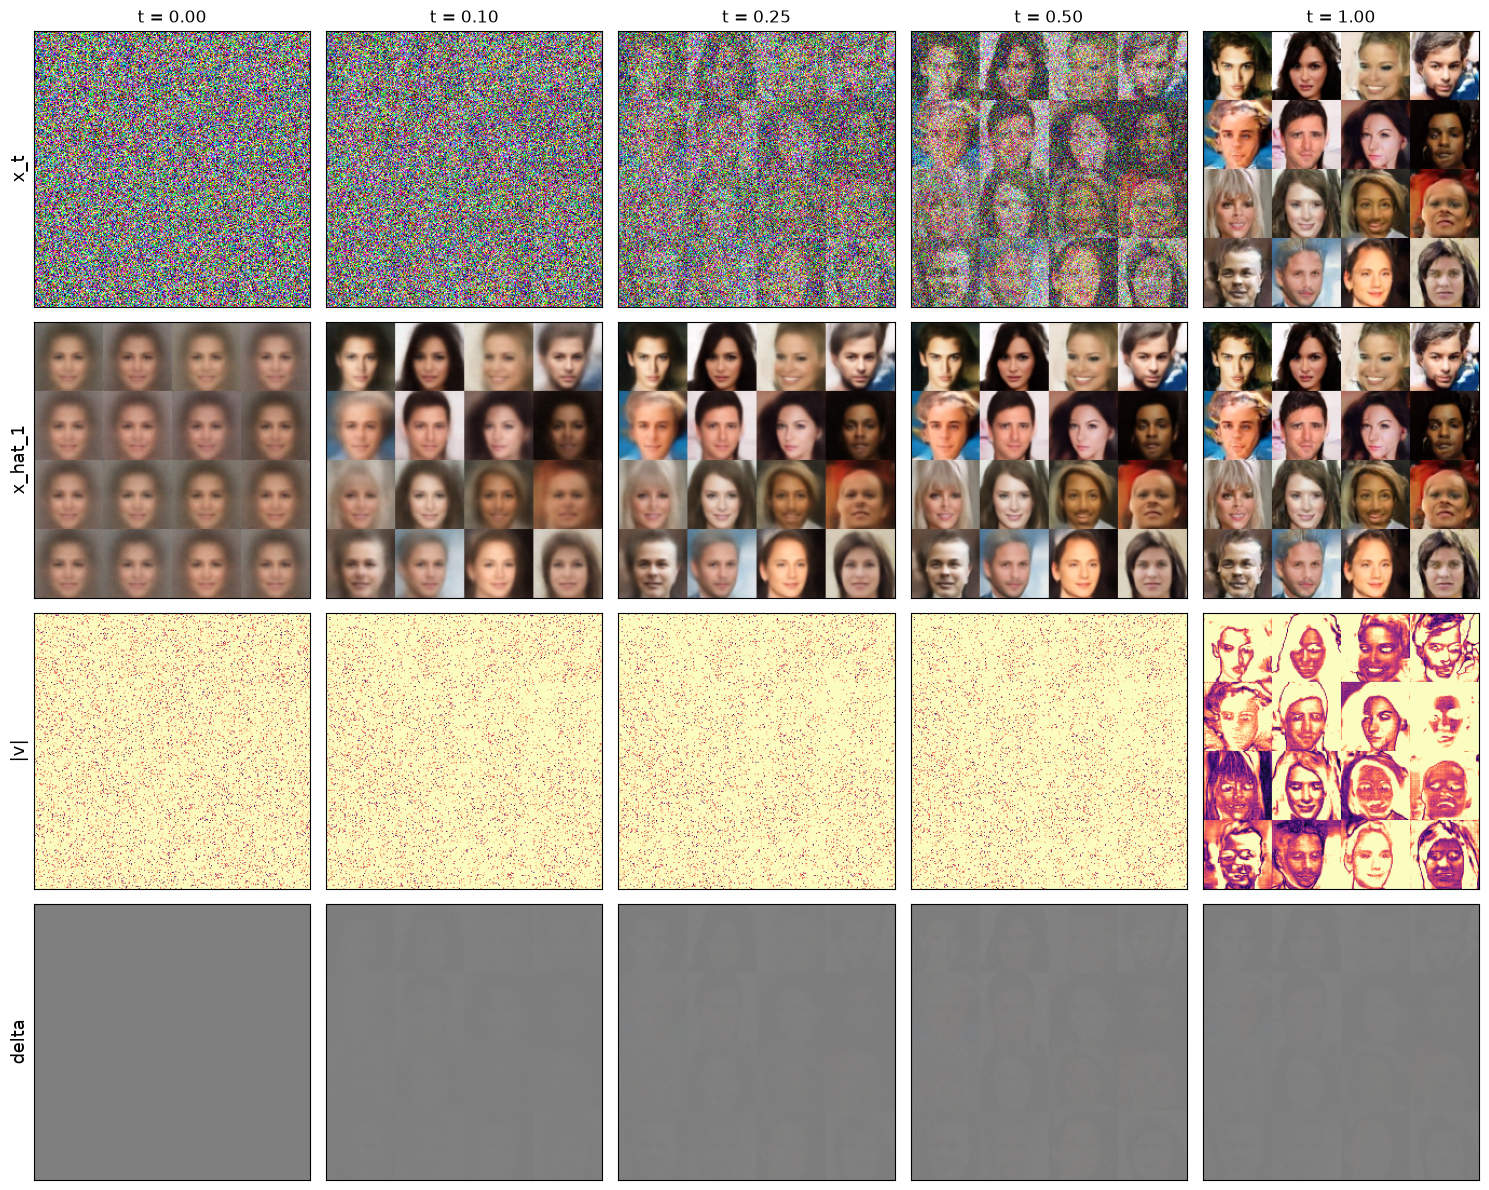

In [5]:
ks = [0, 10, 25, 50, 100]
fig, axes = plt.subplots(4, len(ks), figsize=(3 * len(ks), 12))
vmax = traj.vmax_so_far()

for j, k in enumerate(ks):
    axes[0, j].imshow(traj.x[k].cpu().numpy(), vmin=0, vmax=1)
    axes[1, j].imshow(traj.xhat[k].cpu().numpy(), vmin=0, vmax=1)
    axes[2, j].imshow(traj.vmag[k].cpu().numpy(), cmap="magma", vmin=0, vmax=1)
    axes[3, j].imshow(traj.delta(k).cpu().numpy(), vmin=0, vmax=1)
    axes[0, j].set_title(f"t = {k / traj.T:.2f}")

for ax, lbl in zip(axes[:, 0], ["x_t", "x_hat_1", "|v|", "delta"]):
    ax.set_ylabel(lbl, fontsize=13)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()